# Non-pregnant anemia prevalence and DALYs averted by fortification

We take a "multiplication model" approach here, shifting continuous hemoglobin (as estimated
by GBD) and seeing what impact that has on anemia.

It's important to note that we directly use hemoglobin estimates, which are the first step
of the GBD anemia estimation pipeline. The risks and causes that are related to anemia are
all calculated downstream from this.

In [1]:
import gbd_mapping
import risk_distributions
import pathlib
import pandas as pd, numpy as np
import vivarium_inputs
from vivarium_inputs import utility_data, globals as vi_globals, utilities as vi_utils
from vivarium_gbd_access import gbd
import os, contextlib, warnings, loguru
from lsff_utils.hemoglobin_distribution import hemoglobin_cdf_from_mean_sd

from vivarium_inputs.validation.raw import DataDoesNotExistError, DataAbnormalError
from tqdm.notebook import tqdm

Config: 'input_data:
    cache_data:
        base: True
    intermediary_data_cache_path:
        base: /share/scratch/users/{username}/cache'
Cache Dir: '/share/scratch/users/zmbc/cache'


In [2]:
pd.set_option("display.max_columns", 30)

In [3]:
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

In [4]:
location = "nigeria"
vehicle = "bouillon"
intervention_scenario = "intervention"

In [5]:
# Parameters
location = "india"
vehicle = "rice"
intervention_scenario = "intervention"


## Setup and scenarios

In [6]:
index_cols = ["sex", "age_start", "age_end", "wealth_quintile"]

age_group_ids = [
    2,3,
    388,389,
    6,7,8,9,10,11,12,13,14,15,16,17,18,19,20, 30, 31, 32, 235
]
sex_ids = [1,2]

DRAWS = [f'draw_{i}' for i in range(500)] # NOTE: Some GBD 2021 things return 1,000 but others don't

In [7]:
effective_baseline_coverage = (
    pd.read_csv(f'../0100_data_prep/results/iron/{vehicle}/baseline_fortification/effective_coverage/{location}.csv')
)
assert (effective_baseline_coverage.vehicle_name == vehicle).all()
effective_baseline_coverage = effective_baseline_coverage.drop(columns=["vehicle_name"])
effective_baseline_coverage

,wealth_quintile,sex,age_start,age_end,value
0,fourth,Female,0,5,0.239271
1,fourth,Female,5,15,0.298223
2,fourth,Female,15,30,0.278779
3,fourth,Female,30,50,0.282996
4,fourth,Female,50,125,0.282733
5,fourth,Male,0,5,0.239590
6,fourth,Male,5,15,0.298466
7,fourth,Male,15,30,0.281030
8,fourth,Male,30,50,0.275204
9,fourth,Male,50,125,0.280098


In [8]:
def expand(df):
    for col in sorted(list(set(df.columns) - {'value'})):
        if df[col].isnull().any():
            df = pd.concat([
                df[df[col].notnull()],
                *[df[df[col].isnull()].assign(**{col: value}) for value in df[df[col].notnull()][col].unique()]
            ])
    
    return df

In [9]:
for col, fill_value in [("age_start", 0), ("age_end", 125)]:
    if col not in effective_baseline_coverage.columns:
        effective_baseline_coverage[col] = fill_value
    else:
        effective_baseline_coverage[col] = effective_baseline_coverage[col].fillna(fill_value)

In [10]:
effective_baseline_coverage = expand(effective_baseline_coverage)
effective_baseline_coverage

,wealth_quintile,sex,age_start,age_end,value
0,fourth,Female,0,5,0.239271
1,fourth,Female,5,15,0.298223
2,fourth,Female,15,30,0.278779
3,fourth,Female,30,50,0.282996
4,fourth,Female,50,125,0.282733
5,fourth,Male,0,5,0.239590
6,fourth,Male,5,15,0.298466
7,fourth,Male,15,30,0.281030
8,fourth,Male,30,50,0.275204
9,fourth,Male,50,125,0.280098


In [11]:
effective_counterfactual_coverage = (
    pd.read_csv(f'../0100_data_prep/results/iron/{vehicle}/{intervention_scenario}/intervention_fortification/effective_coverage/{location}.csv')
)
assert (effective_counterfactual_coverage.vehicle_name == vehicle).all()
effective_counterfactual_coverage = effective_counterfactual_coverage.drop(columns=["vehicle_name"])
effective_counterfactual_coverage

,sex,age_start,age_end,wealth_quintile,value
0,Female,0,5,lowest,0.480408
1,Female,0,5,second,0.489627
2,Female,0,5,middle,0.485258
3,Female,0,5,fourth,0.465105
4,Female,0,5,highest,0.414790
5,Female,5,15,lowest,0.518085
6,Female,5,15,second,0.516195
7,Female,5,15,middle,0.503735
8,Female,5,15,fourth,0.480685
9,Female,5,15,highest,0.422331


In [12]:
for col, fill_value in [("age_start", 0), ("age_end", 125)]:
    if col not in effective_counterfactual_coverage.columns:
        effective_counterfactual_coverage[col] = fill_value
    else:
        effective_counterfactual_coverage[col] = effective_counterfactual_coverage[col].fillna(fill_value)

In [13]:
effective_counterfactual_coverage = expand(effective_counterfactual_coverage)
effective_counterfactual_coverage

,sex,age_start,age_end,wealth_quintile,value
0,Female,0,5,lowest,0.480408
1,Female,0,5,second,0.489627
2,Female,0,5,middle,0.485258
3,Female,0,5,fourth,0.465105
4,Female,0,5,highest,0.414790
5,Female,5,15,lowest,0.518085
6,Female,5,15,second,0.516195
7,Female,5,15,middle,0.503735
8,Female,5,15,fourth,0.480685
9,Female,5,15,highest,0.422331


In [14]:
population = (
    pd.read_csv(f'../0100_data_prep/results/population/stratified/{location}.csv')
)

In [15]:
non_pregnant_pop = population.pipe(lambda df: df[df.pregnant == "not_pregnant"]).drop(columns="pregnant")
non_pregnant_pop = non_pregnant_pop.set_index([c for c in non_pregnant_pop.columns if c != 'value']).value
non_pregnant_pop

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    lowest             49649.700497
                               second             43575.622144
                               middle             38689.356750
                               fourth             36440.833935
                               highest            29202.585338
                                                      ...     
Male    95.0       125.000000  lowest             15176.692284
                               second             15848.509818
                               middle             16370.176208
                               fourth             17265.313670
                               highest            21289.473456
Name: value, Length: 250, dtype: float64

In [16]:
population.set_index(["sex", "age_start", "age_end"]).loc[("Female", 25, 30)].value.sum()

59874947.231616504

In [17]:
non_pregnant_pop.loc[("Female", 25, 30)]['lowest']

9317439.611504933

In [18]:
non_pregnant_pop.loc[("Female", 25, 30)].sum()

52388289.46165088

In [19]:
population_age_groups = non_pregnant_pop.reset_index()[["age_start", "age_end"]].drop_duplicates().sort_values("age_start")
population_age_groups

,age_start,age_end
0,0.000000,0.019178
5,0.019178,0.076712
10,0.076712,0.500000
15,0.500000,1.000000
20,1.000000,2.000000
25,2.000000,5.000000
30,5.000000,10.000000
35,10.000000,15.000000
40,15.000000,20.000000
45,20.000000,25.000000


In [20]:
def map_to_population_age_groups(df):
    result = (
        population_age_groups.merge(df, how="cross", suffixes=("", "_orig"))
            .pipe(lambda df: df[(df.age_end <= df.age_end_orig) & (df.age_start >= df.age_start_orig)])
            .drop(columns=["age_start_orig", "age_end_orig"])
    )
    return result

In [21]:
effective_baseline_coverage = map_to_population_age_groups(effective_baseline_coverage).set_index([c for c in effective_baseline_coverage.columns if c != 'value']).value
effective_counterfactual_coverage = map_to_population_age_groups(effective_counterfactual_coverage).set_index([c for c in effective_counterfactual_coverage.columns if c != 'value']).value

In [22]:
if "sex" not in effective_baseline_coverage.index.names:
    # Assume does not vary
    effective_baseline_coverage = pd.concat([
        effective_baseline_coverage.reset_index().assign(sex="Female").set_index(["wealth_quintile", "sex", "age_start", "age_end"]).value,
        effective_baseline_coverage.reset_index().assign(sex="Male").set_index(["wealth_quintile", "sex", "age_start", "age_end"]).value,
    ])

In [23]:
effective_baseline_coverage = effective_baseline_coverage.reset_index().set_index(["sex", "age_start", "age_end", "wealth_quintile"]).value

In [24]:
if "sex" not in effective_counterfactual_coverage.index.names:
    # Assume does not vary
    effective_counterfactual_coverage = pd.concat([
        effective_counterfactual_coverage.reset_index().assign(sex="Female").set_index(["sex", "age_start", "age_end", "wealth_quintile"]).value,
        effective_counterfactual_coverage.reset_index().assign(sex="Male").set_index(["sex", "age_start", "age_end", "wealth_quintile"]).value,
    ])

In [25]:
effective_counterfactual_coverage = effective_counterfactual_coverage.reset_index().set_index(["sex", "age_start", "age_end", "wealth_quintile"]).value

In [26]:
effective_counterfactual_coverage.loc[("Female", 25, 30, "lowest")]

0.4900027896709757

In [27]:
effective_baseline_coverage.loc[("Female", 25, 30, "lowest")]

0.3401179170826516

In [28]:
effective_counterfactual_coverage.loc[("Female", 25, 30, "lowest")]

0.4900027896709757

In [29]:
delta_effective_coverage = effective_counterfactual_coverage.sub(effective_baseline_coverage)
delta_effective_coverage

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    fourth             0.225834
                               highest            0.277436
                               lowest             0.185658
                               middle             0.206281
                               second             0.190897
                                                    ...   
Male    95.0       125.000000  fourth             0.187922
                               highest            0.263533
                               lowest             0.129487
                               middle             0.163211
                               second             0.140935
Name: value, Length: 250, dtype: float64

In [30]:
delta_effective_coverage.loc[("Female", 25, 30, "lowest")]

0.14988487258832411

In [31]:
def reshape_to_vivarium_format(df, location):
    df = vi_utils.reshape(df, value_cols=[c for c in df.columns if 'draw_' in c])
    df = vi_utils.scrub_gbd_conventions(df, location)
    df = vi_utils.split_interval(df, interval_column="age", split_column_prefix="age")
    df = vi_utils.split_interval(df, interval_column="year", split_column_prefix="year")
    df = vi_utils.sort_hierarchical_data(df)
    df.index = df.index.droplevel("location")
    return df

## Pull GBD hemoglobin distributions

In [32]:
me_ids = {
    "hemoglobin_mean": 10487,
    "hemoglobin_sd": 10488,
}

In [33]:
def get_modelable_entity_draws(me_id, location):
    location_id = utility_data.get_location_id(location.title())
    result = gbd.get_modelable_entity_draws(me_id=me_id, location_id=location_id, year_id=2021)
    return (
        reshape_to_vivarium_format(result, location.title())
            .droplevel(["year_start", "year_end", "measure_id", "metric_id", "model_version_id", "modelable_entity_id"])[DRAWS]
            .copy()
    )

In [34]:
hgb_mean = get_modelable_entity_draws(me_ids["hemoglobin_mean"], location)
hgb_mean

draw_0      draw_1      draw_2      draw_3  \
sex    age_start age_end                                                      
Female 0.000000  0.019178    141.027303  141.174892  143.047093  142.497768   
       0.019178  0.076712    128.185915  129.096397  129.130806  127.546092   
       0.076712  0.500000    103.541148  104.218523  102.321094  104.327579   
       0.500000  1.000000    101.917809   99.823676  100.483745  100.428266   
       1.000000  2.000000    101.808200  103.457343  102.146844  103.058795   
       2.000000  5.000000    106.297867  106.219133  105.789212  107.260720   
       5.000000  10.000000   112.932920  111.768831  112.598540  114.147894   
       10.000000 15.000000   115.889117  117.854010  116.651884  116.435834   
       15.000000 20.000000   117.312802  117.869717  117.696658  118.290512   
       20.000000 25.000000   118.617583  117.381244  117.562883  116.463839   
       25.000000 30.000000   118.136225  118.984193  118.330466  117.484197   
       30.000000 35.000000   118.468947  117.409679  117.886880  119.228899   
       35.000000 40.000000   117.893922  117.756202  118.469227  118.035053   
       40.000000 45.000000   117.705099  117.438677  117.891058  117.526008   
       45.000000 50.000000   118.863416  118.956356  117.862423  118.694166   
       50.000000 55.000000   117.380298  115.684488  117.082839  117.521103   
       55.000000 60.000000   115.610201  115.858632  116.824778  116.971145   
       60.000000 65.000000   115.852172  115.273742  114.679645  115.057166   
       65.000000 70.000000   112.799956  114.029249  112.513289  113.319053   
       70.000000 75.000000   111.763028  110.907571  111.248801  110.229346   
       75.000000 80.000000   106.694860  105.688161  106.061586  105.665603   
       80.000000 85.000000   105.375787  105.408475  105.314517  107.634883   
       85.000000 90.000000   100.573661  100.988738   98.813280   99.706145   
       90.000000 95.000000    97.373246   97.761692   97.824092   97.656022   
       95.000000 125.000000   95.150708   95.688588   94.653440   94.380913   
Male   0.000000  0.019178    146.600654  149.103908  146.074897  145.748027   
       0.019178  0.076712    128.593451  128.987080  131.564522  129.046613   
       0.076712  0.500000    102.882001  103.484281  102.379468  102.302975   
       0.500000  1.000000     98.720550  100.044084   99.267918  100.076804   
       1.000000  2.000000    101.799264  101.036897  102.067002  102.340244   
       2.000000  5.000000    107.195733  107.108687  106.303427  107.176671   
       5.000000  10.000000   115.943763  116.573107  114.252198  113.966774   
       10.000000 15.000000   125.861685  126.103005  123.731518  125.853467   
       15.000000 20.000000   138.148186  139.196158  138.577766  140.412738   
       20.000000 25.000000   145.705670  143.628038  144.447657  145.036625   
       25.000000 30.000000   143.206791  144.192168  144.708908  142.243978   
       30.000000 35.000000   143.104472  145.407658  144.512082  143.314688   
       35.000000 40.000000   143.022415  141.891966  143.895938  141.822267   
       40.000000 45.000000   142.575032  141.418982  142.295188  141.503041   
       45.000000 50.000000   141.450799  142.687529  139.176123  140.952480   
       50.000000 55.000000   138.187591  140.164931  139.259715  141.275545   
       55.000000 60.000000   135.036605  134.464782  134.025679  133.016133   
       60.000000 65.000000   131.931505  132.888573  130.701815  131.483537   
       65.000000 70.000000   128.500505  127.922563  128.410141  128.344826   
       70.000000 75.000000   122.092349  122.015506  121.558645  122.075910   
       75.000000 80.000000   113.648012  114.150699  114.133169  113.393346   
       80.000000 85.000000   111.213129  111.511647  111.224695  113.696862   
       85.000000 90.000000   108.957315  109.468162  107.835589  108.453981   
       90.000000 95.000000   104.826207  102.838567  103.076523  105.765753   
    

In [35]:
hgb_mean.loc[("Female", 25, 30)].mean()

117.6864790279587

In [36]:
hemoglobin_mean_disparities = pd.read_csv(f'../0100_data_prep/results/hemoglobin/mean_disparities/{location}.csv')
hemoglobin_mean_disparities = (
    map_to_population_age_groups(hemoglobin_mean_disparities[hemoglobin_mean_disparities.pregnant == "not_pregnant"].drop(columns=["pregnant"]))
        .set_index(["sex", "age_start", "age_end", "wealth_quintile"]).value
)
hemoglobin_mean_disparities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    lowest             103.655561
                               second             105.257986
                               middle             105.397530
                               fourth             106.765336
                               highest            107.989017
                                                     ...    
Male    95.0       125.000000  lowest             115.022635
                               second             116.108207
                               middle             116.488978
                               fourth             117.310740
                               highest            118.402649
Name: value, Length: 250, dtype: float64

In [37]:
wealth_quintile_probabilities = pd.read_csv(f'../0100_data_prep/results/wealth_quintile_probabilities/{location}.csv')
wealth_quintile_probabilities

,sex,age_start,age_end,pregnant,lowest,second,middle,fourth,highest
0,Female,0.0,5.0,not_pregnant,0.251317,0.220571,0.195838,0.184456,0.147818
1,Female,5.0,15.0,not_pregnant,0.269038,0.219459,0.193766,0.172569,0.145167
2,Female,15.0,30.0,not_pregnant,0.177853,0.202279,0.211418,0.210441,0.198009
3,Female,15.0,30.0,pregnant,0.221117,0.222530,0.215087,0.182296,0.158970
4,Female,30.0,50.0,not_pregnant,0.172597,0.187138,0.199031,0.213495,0.227738
5,Female,30.0,50.0,pregnant,0.316131,0.181401,0.129805,0.169147,0.203517
6,Female,50.0,125.0,not_pregnant,0.188708,0.187540,0.191253,0.199636,0.232863
7,Male,0.0,5.0,not_pregnant,0.242600,0.215610,0.200229,0.183923,0.157639
8,Male,5.0,15.0,not_pregnant,0.261604,0.217675,0.190718,0.176545,0.153458
9,Male,15.0,30.0,not_pregnant,0.169172,0.205794,0.214029,0.208330,0.202675


In [38]:
wealth_quintile_probabilities = (
    map_to_population_age_groups(wealth_quintile_probabilities[wealth_quintile_probabilities.pregnant == "not_pregnant"].drop(columns=["pregnant"]))
        .set_index(["sex", "age_start", "age_end"])
)
wealth_quintile_probabilities.columns.name = 'wealth_quintile'
wealth_quintile_probabilities = wealth_quintile_probabilities.stack()
wealth_quintile_probabilities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    lowest             0.251317
                               second             0.220571
                               middle             0.195838
                               fourth             0.184456
                               highest            0.147818
                                                    ...   
Male    95.0       125.000000  lowest             0.176575
                               second             0.184392
                               middle             0.190461
                               fourth             0.200876
                               highest            0.247696
Length: 250, dtype: float64

In [39]:
assert np.allclose(wealth_quintile_probabilities.groupby(["sex", "age_start", "age_end"]).sum(), 1.0)

In [40]:
def distribute_by_disparities(df, disparities):
    pre_disparity_groups = df.mul(wealth_quintile_probabilities, axis=0).groupby([c for c in df.index.names if c != 'wealth_quintile']).sum()
    print('Before distributing by disparities:')
    display(pre_disparity_groups)

    df = df.mul(disparities, axis=0)

    scale_factor = pre_disparity_groups / df.mul(wealth_quintile_probabilities, axis=0).groupby([c for c in df.index.names if c != 'wealth_quintile']).sum()
    print(f'Scale factor: {scale_factor}')

    df = df * scale_factor

    assert np.allclose(
        df.mul(wealth_quintile_probabilities, axis=0).groupby([c for c in df.index.names if c != 'wealth_quintile']).sum(),
        pre_disparity_groups,
    )

    return df

In [41]:
hgb_mean = distribute_by_disparities(hgb_mean, hemoglobin_mean_disparities)

Before distributing by disparities:


draw_0      draw_1      draw_2      draw_3  \
sex    age_start age_end                                                      
Female 0.000000  0.019178    141.027303  141.174892  143.047093  142.497768   
       0.019178  0.076712    128.185915  129.096397  129.130806  127.546092   
       0.076712  0.500000    103.541148  104.218523  102.321094  104.327579   
       0.500000  1.000000    101.917809   99.823676  100.483745  100.428266   
       1.000000  2.000000    101.808200  103.457343  102.146844  103.058795   
       2.000000  5.000000    106.297867  106.219133  105.789212  107.260720   
       5.000000  10.000000   112.932920  111.768831  112.598540  114.147894   
       10.000000 15.000000   115.889117  117.854010  116.651884  116.435834   
       15.000000 20.000000   117.312802  117.869717  117.696658  118.290512   
       20.000000 25.000000   118.617583  117.381244  117.562883  116.463839   
       25.000000 30.000000   118.136225  118.984193  118.330466  117.484197   
       30.000000 35.000000   118.468947  117.409679  117.886880  119.228899   
       35.000000 40.000000   117.893922  117.756202  118.469227  118.035053   
       40.000000 45.000000   117.705099  117.438677  117.891058  117.526008   
       45.000000 50.000000   118.863416  118.956356  117.862423  118.694166   
       50.000000 55.000000   117.380298  115.684488  117.082839  117.521103   
       55.000000 60.000000   115.610201  115.858632  116.824778  116.971145   
       60.000000 65.000000   115.852172  115.273742  114.679645  115.057166   
       65.000000 70.000000   112.799956  114.029249  112.513289  113.319053   
       70.000000 75.000000   111.763028  110.907571  111.248801  110.229346   
       75.000000 80.000000   106.694860  105.688161  106.061586  105.665603   
       80.000000 85.000000   105.375787  105.408475  105.314517  107.634883   
       85.000000 90.000000   100.573661  100.988738   98.813280   99.706145   
       90.000000 95.000000    97.373246   97.761692   97.824092   97.656022   
       95.000000 125.000000   95.150708   95.688588   94.653440   94.380913   
Male   0.000000  0.019178    146.600654  149.103908  146.074897  145.748027   
       0.019178  0.076712    128.593451  128.987080  131.564522  129.046613   
       0.076712  0.500000    102.882001  103.484281  102.379468  102.302975   
       0.500000  1.000000     98.720550  100.044084   99.267918  100.076804   
       1.000000  2.000000    101.799264  101.036897  102.067002  102.340244   
       2.000000  5.000000    107.195733  107.108687  106.303427  107.176671   
       5.000000  10.000000   115.943763  116.573107  114.252198  113.966774   
       10.000000 15.000000   125.861685  126.103005  123.731518  125.853467   
       15.000000 20.000000   138.148186  139.196158  138.577766  140.412738   
       20.000000 25.000000   145.705670  143.628038  144.447657  145.036625   
       25.000000 30.000000   143.206791  144.192168  144.708908  142.243978   
       30.000000 35.000000   143.104472  145.407658  144.512082  143.314688   
       35.000000 40.000000   143.022415  141.891966  143.895938  141.822267   
       40.000000 45.000000   142.575032  141.418982  142.295188  141.503041   
       45.000000 50.000000   141.450799  142.687529  139.176123  140.952480   
       50.000000 55.000000   138.187591  140.164931  139.259715  141.275545   
       55.000000 60.000000   135.036605  134.464782  134.025679  133.016133   
       60.000000 65.000000   131.931505  132.888573  130.701815  131.483537   
       65.000000 70.000000   128.500505  127.922563  128.410141  128.344826   
       70.000000 75.000000   122.092349  122.015506  121.558645  122.075910   
       75.000000 80.000000   113.648012  114.150699  114.133169  113.393346   
       80.000000 85.000000   111.213129  111.511647  111.224695  113.696862   
       85.000000 90.000000   108.957315  109.468162  107.835589  108.453981   
       90.000000 95.000000   104.826207  102.838567  103.076523  105.765753   
    

Scale factor:                                draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                        
Female 0.000000  0.019178    0.009473  0.009473  0.009473  0.009473  0.009473   
       0.019178  0.076712    0.009473  0.009473  0.009473  0.009473  0.009473   
       0.076712  0.500000    0.009473  0.009473  0.009473  0.009473  0.009473   
       0.500000  1.000000    0.009473  0.009473  0.009473  0.009473  0.009473   
       1.000000  2.000000    0.009473  0.009473  0.009473  0.009473  0.009473   
       2.000000  5.000000    0.009473  0.009473  0.009473  0.009473  0.009473   
       5.000000  10.000000   0.009011  0.009011  0.009011  0.009011  0.009011   
       10.000000 15.000000   0.009011  0.009011  0.009011  0.009011  0.009011   
       15.000000 20.000000   0.008569  0.008569  0.008569  0.008569  0.008569   
       20.000000 25.000000   0.008569  0.008569  0.008569  0.008569  0.008569   
       25.0000

In [42]:
hgb_mean.columns.name = "draw"
hgb_mean = hgb_mean.stack().rename("mean")

In [43]:
hgb_sd = get_modelable_entity_draws(me_ids["hemoglobin_sd"], location)
hgb_sd

draw_0     draw_1     draw_2     draw_3  \
sex    age_start age_end                                                  
Female 0.000000  0.019178    11.056572  15.419496  12.937057  14.108613   
       0.019178  0.076712    18.143206  17.170122  18.638921  21.675732   
       0.076712  0.500000    11.519491  14.027332  13.723109  14.417308   
       0.500000  1.000000    13.756756  14.711771  13.648304  13.187534   
       1.000000  2.000000    14.325459  16.843282  16.709555  15.864417   
       2.000000  5.000000    16.864334  16.488876  16.574293  16.946859   
       5.000000  10.000000   14.225182  14.168108  12.948419  12.913613   
       10.000000 15.000000   13.709243  13.495770  11.389442  15.925441   
       15.000000 20.000000   13.561928  15.733414  13.751380  15.264811   
       20.000000 25.000000   17.877538  15.796879  16.381351  14.863829   
       25.000000 30.000000   16.815011  16.994822  15.316674  15.690873   
       30.000000 35.000000   16.621743  15.047877  16.867962  15.976469   
       35.000000 40.000000   14.396311  15.728416  16.175030  15.550384   
       40.000000 45.000000   16.718798  15.378787  17.134685  16.801107   
       45.000000 50.000000   17.032453  15.404674  16.578969  18.835821   
       50.000000 55.000000   15.717267  15.389592  14.263427  15.514466   
       55.000000 60.000000   12.958764  14.368135  16.001020  15.681634   
       60.000000 65.000000   14.203046  14.792499  14.244354  14.557884   
       65.000000 70.000000   12.468907  15.525386  14.499738  14.166835   
       70.000000 75.000000   16.333369  16.631346  16.833404  15.235709   
       75.000000 80.000000   22.254054  24.403128  20.115561  23.155481   
       80.000000 85.000000   24.100034  24.539483  24.989374  26.511926   
       85.000000 90.000000   36.306586  33.251947  37.348512  32.257547   
       90.000000 95.000000   38.914197  41.875007  39.460541  40.321736   
       95.000000 125.000000  38.019009  39.773450  39.091306  40.811093   
Male   0.000000  0.019178     7.610899   6.575979   7.453095   6.250333   
       0.019178  0.076712    16.977021  18.465539  16.510252  21.378982   
       0.076712  0.500000     9.721262  12.425339  14.429252  13.617889   
       0.500000  1.000000    14.652405  12.306607  13.147011  14.384103   
       1.000000  2.000000    13.806197  12.868476  13.713812  14.321067   
       2.000000  5.000000    14.572863  13.560881  13.249884  13.447389   
       5.000000  10.000000   12.573757   7.057425   9.593659   9.916708   
       10.000000 15.000000   11.260913  12.769954   9.948129  11.258765   
       15.000000 20.000000   11.470756  15.361375  13.757213  15.839422   
       20.000000 25.000000   16.818841  15.146760  14.406426  15.531786   
       25.000000 30.000000   14.325444  14.905894  14.724530  12.324918   
       30.000000 35.000000   16.155267  16.364407  15.748614  15.395269   
       35.000000 40.000000   17.000588  14.962367  16.688472  15.727331   
       40.000000 45.000000   16.215645  16.148306  15.713011  15.286601   
       45.000000 50.000000   16.866309  17.598236  14.838259  17.183189   
       50.000000 55.000000   16.298999  17.308050  17.941748  18.389619   
       55.000000 60.000000   19.614086  19.237907  18.023727  18.054980   
       60.000000 65.000000   17.017625  19.435720  17.143083  16.953227   
       65.000000 70.000000   17.246434  17.477513  19.252672  18.443892   
       70.000000 75.000000   18.666848  17.255199  17.201503  17.486489   
       75.000000 80.000000   19.081333  16.399954  20.715293  21.595394   
       80.000000 85.000000   21.153456  22.487688  23.106116  22.546762   
       85.000000 90.000000   23.662495  24.946716  26.106795  23.226613   
       90.000000 95.000000   27.527042  30.766501  28.349045  28.340500   
       95.000000 125.000000  39.559564  39.138167  37.453939  35.318036   

                                draw_4     draw_5     draw_6     draw_7  \
sex    age_start age_end                                

In [44]:
hemoglobin_sd_disparities = pd.read_csv(f'../0100_data_prep/results/hemoglobin/sd_disparities/{location}.csv')
hemoglobin_sd_disparities = (
    map_to_population_age_groups(hemoglobin_sd_disparities[hemoglobin_sd_disparities.pregnant == "not_pregnant"].drop(columns=["pregnant"]))
        .set_index(["sex", "age_start", "age_end", "wealth_quintile"]).value
)
hemoglobin_sd_disparities

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    lowest             14.697789
                               second             14.743958
                               middle             15.145306
                               fourth             15.145327
                               highest            14.592007
                                                    ...    
Male    95.0       125.000000  lowest             16.135241
                               second             16.281235
                               middle             16.559569
                               fourth             16.266386
                               highest            15.538198
Name: value, Length: 250, dtype: float64

In [45]:
hgb_sd = distribute_by_disparities(hgb_sd, hemoglobin_sd_disparities)
hgb_sd

Before distributing by disparities:


draw_0     draw_1     draw_2     draw_3  \
sex    age_start age_end                                                  
Female 0.000000  0.019178    11.056572  15.419496  12.937057  14.108613   
       0.019178  0.076712    18.143206  17.170122  18.638921  21.675732   
       0.076712  0.500000    11.519491  14.027332  13.723109  14.417308   
       0.500000  1.000000    13.756756  14.711771  13.648304  13.187534   
       1.000000  2.000000    14.325459  16.843282  16.709555  15.864417   
       2.000000  5.000000    16.864334  16.488876  16.574293  16.946859   
       5.000000  10.000000   14.225182  14.168108  12.948419  12.913613   
       10.000000 15.000000   13.709243  13.495770  11.389442  15.925441   
       15.000000 20.000000   13.561928  15.733414  13.751380  15.264811   
       20.000000 25.000000   17.877538  15.796879  16.381351  14.863829   
       25.000000 30.000000   16.815011  16.994822  15.316674  15.690873   
       30.000000 35.000000   16.621743  15.047877  16.867962  15.976469   
       35.000000 40.000000   14.396311  15.728416  16.175030  15.550384   
       40.000000 45.000000   16.718798  15.378787  17.134685  16.801107   
       45.000000 50.000000   17.032453  15.404674  16.578969  18.835821   
       50.000000 55.000000   15.717267  15.389592  14.263427  15.514466   
       55.000000 60.000000   12.958764  14.368135  16.001020  15.681634   
       60.000000 65.000000   14.203046  14.792499  14.244354  14.557884   
       65.000000 70.000000   12.468907  15.525386  14.499738  14.166835   
       70.000000 75.000000   16.333369  16.631346  16.833404  15.235709   
       75.000000 80.000000   22.254054  24.403128  20.115561  23.155481   
       80.000000 85.000000   24.100034  24.539483  24.989374  26.511926   
       85.000000 90.000000   36.306586  33.251947  37.348512  32.257547   
       90.000000 95.000000   38.914197  41.875007  39.460541  40.321736   
       95.000000 125.000000  38.019009  39.773450  39.091306  40.811093   
Male   0.000000  0.019178     7.610899   6.575979   7.453095   6.250333   
       0.019178  0.076712    16.977021  18.465539  16.510252  21.378982   
       0.076712  0.500000     9.721262  12.425339  14.429252  13.617889   
       0.500000  1.000000    14.652405  12.306607  13.147011  14.384103   
       1.000000  2.000000    13.806197  12.868476  13.713812  14.321067   
       2.000000  5.000000    14.572863  13.560881  13.249884  13.447389   
       5.000000  10.000000   12.573757   7.057425   9.593659   9.916708   
       10.000000 15.000000   11.260913  12.769954   9.948129  11.258765   
       15.000000 20.000000   11.470756  15.361375  13.757213  15.839422   
       20.000000 25.000000   16.818841  15.146760  14.406426  15.531786   
       25.000000 30.000000   14.325444  14.905894  14.724530  12.324918   
       30.000000 35.000000   16.155267  16.364407  15.748614  15.395269   
       35.000000 40.000000   17.000588  14.962367  16.688472  15.727331   
       40.000000 45.000000   16.215645  16.148306  15.713011  15.286601   
       45.000000 50.000000   16.866309  17.598236  14.838259  17.183189   
       50.000000 55.000000   16.298999  17.308050  17.941748  18.389619   
       55.000000 60.000000   19.614086  19.237907  18.023727  18.054980   
       60.000000 65.000000   17.017625  19.435720  17.143083  16.953227   
       65.000000 70.000000   17.246434  17.477513  19.252672  18.443892   
       70.000000 75.000000   18.666848  17.255199  17.201503  17.486489   
       75.000000 80.000000   19.081333  16.399954  20.715293  21.595394   
       80.000000 85.000000   21.153456  22.487688  23.106116  22.546762   
       85.000000 90.000000   23.662495  24.946716  26.106795  23.226613   
       90.000000 95.000000   27.527042  30.766501  28.349045  28.340500   
       95.000000 125.000000  39.559564  39.138167  37.453939  35.318036   

                                draw_4     draw_5     draw_6     draw_7  \
sex    age_start age_end                                

Scale factor:                                draw_0    draw_1    draw_2    draw_3    draw_4  \
sex    age_start age_end                                                        
Female 0.000000  0.019178    0.067283  0.067283  0.067283  0.067283  0.067283   
       0.019178  0.076712    0.067283  0.067283  0.067283  0.067283  0.067283   
       0.076712  0.500000    0.067283  0.067283  0.067283  0.067283  0.067283   
       0.500000  1.000000    0.067283  0.067283  0.067283  0.067283  0.067283   
       1.000000  2.000000    0.067283  0.067283  0.067283  0.067283  0.067283   
       2.000000  5.000000    0.067283  0.067283  0.067283  0.067283  0.067283   
       5.000000  10.000000   0.064429  0.064429  0.064429  0.064429  0.064429   
       10.000000 15.000000   0.064429  0.064429  0.064429  0.064429  0.064429   
       15.000000 20.000000   0.061866  0.061866  0.061866  0.061866  0.061866   
       20.000000 25.000000   0.061866  0.061866  0.061866  0.061866  0.061866   
       25.0000

draw_0     draw_1     draw_2  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   lowest           10.934018  15.248582  12.793660   
                            second           10.968365  15.296482  12.833848   
                            middle           11.266937  15.712871  13.183201   
                            fourth           11.266953  15.712893  13.183219   
                            highest          10.855325  15.138837  12.701583   
...                                                ...        ...        ...   
Male   95.0      125.000000 lowest           39.593434  39.171676  37.486005   
                            second           39.951681  39.526107  37.825184   
                            middle           40.634671  40.201822  38.471821   
                            fourth           39.915244  39.490059  37.790687   
                            highest          38.128383  37.722231  36.098934   

                                                draw_3     draw_4     draw_5  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   lowest           13.952230  12.875777  12.438394   
                            second           13.996057  12.916223  12.477466   
                            middle           14.377047  13.267818  12.817118   
                            fourth           14.377067  13.267837  12.817136   
                            highest          13.851814  12.783109  12.348874   
...                                                ...        ...        ...   
Male   95.0      125.000000 lowest           35.348274  32.781236  35.987657   
                            second           35.668110  33.077845  36.313278   
                            middle           36.277871  33.643325  36.934068   
                            fourth           35.635580  33.047678  36.280160   
                            highest          34.040304  31.568253  34.656028   

                                                draw_6     draw_7     draw_8  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   lowest           17.558029  12.954448  11.780678   
                            second           17.613183  12.995141  11.817684   
                            middle           18.092636  13.348885  12.139375   
                            fourth           18.092661  13.348903  12.139392   
                            highest          17.431663  12.861214  11.695891   
...                                                ...        ...        ...   
Male   95.0      125.000000 lowest           34.433213  37.960502  35.016623   
                            second           34.744769  38.303974  35.333459   
                            middle           35.338745  38.958796  35.937499   
                            fourth           34.713082  38.269040  35.301234   
                            highest          33.159102  36.555874  33.720925   

                                                draw_9    draw_10    draw_11  \
sex    age_start age_end    wealth_quintile                                    
Female 0.0       0.019178   lowest           13.384399  15.081859  12.944224   
                            second           13.426443  15.129235  12.984885   
                            middle           13.791927  15.541072  13.338349   
                            fourth           13.791946  15.541093  13.338368   
                            highest          13.288071  14.973314  12.851063   
...                                                ...        ...        ...   
Male   95.0      125.000000 lowest           36.845113  36.234460  41.797558   
                            second           37.178493  36.562314  42.175748   
                            middle           37.814075  37.187362  42.896760   
                            fourth           

In [46]:
hgb_sd.columns.name = "draw"
hgb_sd = hgb_sd.stack().rename("sd")
hgb_sd

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    lowest           draw_0      10.934018
                                                draw_1      15.248582
                                                draw_2      12.793660
                                                draw_3      13.952230
                                                draw_4      12.875777
                                                              ...    
Male    95.0       125.000000  highest          draw_495    38.237787
                                                draw_496    36.635558
                                                draw_497    36.002955
                                                draw_498    34.653317
                                                draw_499    31.370762
Name: sd, Length: 125000, dtype: float64

In [47]:
hgb_mean.loc[("Female", 25, 30, "lowest")].mean()

115.99193465619575

In [48]:
hgb_sd.loc[("Female", 25, 30, "lowest")].mean()

16.204554414892446

## Effect size and adjustment for iron responsiveness

We assume that our overall effect size is composed of two parts:
some people respond to iron with a constant shift (no individual heterogeneity)
and other people are "not responsive" and their hemoglobin doesn't
change at all.

This is similar to how GBD models the iron deficiency risk factor.
I believe we got the lists of sequelae below from them.

As a rough approximation, we assume that our mean difference value
(from the literature) was from a population that had the global prevalence
split between iron-responsive and non-iron-responsive.

**Note: We assume everyone who is not anemic is iron-responsive.**

In [49]:
fortification_hemoglobin_mean_difference = (
    pd.read_csv('../0100_data_prep/results/iron/fortification_hemoglobin_effects.csv')
        .set_index('vehicle_name').value
        .loc[vehicle]
)
fortification_hemoglobin_mean_difference

3.25

In [50]:
# Cleaned this up from https://github.com/ihmeuw/vivarium_research_lsff/blob/1cb465a752d299401ae366db537dc8d557162184/multiplication_models/iron_model_U5.ipynb,
# but have not checked it in extreme detail.
iron_responsive_anemia_sequelae = [
    gbd_mapping.sequelae.mild_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.moderate_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.severe_anemia_due_to_schistosomiasis,
    gbd_mapping.sequelae.mild_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.moderate_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.severe_anemia_due_to_hookworm_disease,
    gbd_mapping.sequelae.mild_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.severe_anemia_due_to_other_neglected_tropical_diseases,
    gbd_mapping.sequelae.mild_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.moderate_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.severe_anemia_due_to_maternal_hemorrhage,
    gbd_mapping.sequelae.mild_iron_deficiency_anemia,
    gbd_mapping.sequelae.moderate_iron_deficiency_anemia,
    gbd_mapping.sequelae.severe_iron_deficiency_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.severe_anemia_due_to_other_infectious_diseases,
    gbd_mapping.sequelae.menstrual_disorders_with_mild_anemia,
    gbd_mapping.sequelae.menstrual_disorders_with_moderate_anemia,
    gbd_mapping.sequelae.menstrual_disorders_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_mild_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_moderate_anemia,
    gbd_mapping.sequelae.uterine_fibroids_symptomatic_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_mild_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_moderate_anemia,
    gbd_mapping.sequelae.asymptomatic_pud_with_severe_anemia,
    gbd_mapping.sequelae.mildy_symptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.mildly_symptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.mildy_symptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.moderately_symptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.asymptomatic_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_mdoerate_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_3_chronic_kidney_disease_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mdoerate_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_4_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.stage_5_chronic_kidney_disease_untreated_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_mild_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_moderate_anemia,
    gbd_mapping.sequelae.vitamin_a_deficiency_with_severe_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_mild_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_moderate_anemia,
    gbd_mapping.sequelae.ulcerative_colitis_with_severe_anemia,
    gbd_mapping.sequelae.crohns_disease_with_mild_anemia,
    gbd_mapping.sequelae.crohns_disease_with_moderate_anemia,
    gbd_mapping.sequelae.crohns_disease_with_severe_anemia,
    gbd_mapping.sequelae.complicated_pud_with_mild_anemia,
    gbd_mapping.sequelae.complicated_pud_with_moderate_anemia,
    gbd_mapping.sequelae.complicated_pud_with_severe_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.complicated_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_mild_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_moderate_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_pud_with_severe_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_mild_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_moderate_anemia,
    gbd_mapping.sequelae.severe_acute_uncomplicated_gastritis_duodenitis_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_mild_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_moderate_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_1_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_type_2_diabetes_mellitus_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_hypertension_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_glomerulonephritis_with_severe_anemia,
    gbd_mapping.sequelae.end_stage_renal_disease_on_dialysis_due_to_other_and_unspecified_causes_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_b_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_hepatitis_c_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_alcohol_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_other_decompensated_with_severe_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_mild_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_moderate_anemia,
    gbd_mapping.sequelae.cirrhosis_and_other_chronic_liver_diseases_due_to_nash_decompensated_with_severe_anemia,
]

In [51]:
non_iron_responsive_anemia_sequelae = [
    gbd_mapping.sequelae.mild_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.moderate_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.severe_anemia_due_to_other_hemoglobinopathies_and_hemolytic_anemias,
    gbd_mapping.sequelae.mild_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_b_thalassemia_trait,
    gbd_mapping.sequelae.mild_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_hemoglobin_e_trait,
    gbd_mapping.sequelae.mild_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.moderate_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.severe_anemia_due_to_sickle_cell_trait,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_mild_anemia,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_moderate_anemia,
    gbd_mapping.sequelae.hemizygous_g6pd_deficiency_with_severe_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.moderate_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.severe_anemia_due_to_malaria_parasitemia_pfpr,
    gbd_mapping.sequelae.mild_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.moderate_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_anemia_due_to_homozygous_sickle_cell_and_severe_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.mild_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.moderate_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.severe_anemia_due_to_hemoglobin_sc_disease,
    gbd_mapping.sequelae.mild_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.moderate_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_anemia_due_to_mild_sickle_cell_beta_thalassemia,
    gbd_mapping.sequelae.severe_malaria_with_mild_anemia,
    gbd_mapping.sequelae.severe_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.severe_malaria_with_severe_anemia,
    gbd_mapping.sequelae.mild_malaria_with_mild_anemia,
    gbd_mapping.sequelae.mild_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.mild_malaria_with_severe_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_mild_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_moderate_anemia,
    gbd_mapping.sequelae.moderate_malaria_with_severe_anemia,
    gbd_mapping.sequelae.early_hiv_with_mild_anemia,
    gbd_mapping.sequelae.early_hiv_with_moderate_anemia,
    gbd_mapping.sequelae.early_hiv_with_severe_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_mild_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_moderate_anemia,
    gbd_mapping.sequelae.symptomatic_hiv_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_with_antiretroviral_treatment_with_severe_anemia,
    gbd_mapping.sequelae.aids_with_mild_anemia,
    gbd_mapping.sequelae.aids_with_moderate_anemia,
    gbd_mapping.sequelae.aids_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_drug_susceptible_tuberculosis_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_multidrug_resistant_tuberculosis_without_extensive_drug_resistance_with_severe_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_mild_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_moderate_anemia,
    gbd_mapping.sequelae.hiv_aids_extensively_drug_resistant_tuberculosis_with_severe_anemia,
    gbd_mapping.sequelae.mild_anemia_due_to_malaria_vivax_pvpr,
    gbd_mapping.sequelae.moderate_anemia_due_to_malaria_vivax_pvpr,
    gbd_mapping.sequelae.severe_anemia_due_to_malaria_vivax_pvpr,
]

In [52]:
len(iron_responsive_anemia_sequelae)

138

In [53]:
len(non_iron_responsive_anemia_sequelae)

60

In [54]:
def pull_sequelae_prevalence(location, sequelae):
    result = 0
    # There are tons of validation warnings -- look into these more?
    loguru.logger.disable("vivarium_inputs.validation.raw")
    for sequela in sequelae:
        try:
            sequela_prevalence = vivarium_inputs.get_measure(sequela, "prevalence", location.title()).droplevel(["location"])
        # There are even some errors, caused by all-zero values
        except DataDoesNotExistError as e:
            assert 'zero' in str(e)
            continue
        except DataAbnormalError as e:
            assert 'zero' in str(e)
            continue

        # AFAIK these are not mutually exclusive; standard GBD assumption is independence
        result += sequela_prevalence * (1 - result)
    
    loguru.logger.enable("vivarium_inputs.validation.raw")
    
    return result

In [55]:
global_population = vivarium_inputs.get_population_structure("Global").droplevel("location").value
global_population

sex     age_start  age_end     year_start  year_end
Female  0.000000   0.019178    2021        2022        1.183499e+06
        0.019178   0.076712    2021        2022        3.525317e+06
        0.076712   0.500000    2021        2022        2.598414e+07
        0.500000   1.000000    2021        2022        3.054267e+07
        1.000000   2.000000    2021        2022        6.209731e+07
        2.000000   5.000000    2021        2022        1.948595e+08
        5.000000   10.000000   2021        2022        3.325771e+08
        10.000000  15.000000   2021        2022        3.229261e+08
        15.000000  20.000000   2021        2022        3.036500e+08
        20.000000  25.000000   2021        2022        2.937520e+08
        25.000000  30.000000   2021        2022        2.909873e+08
        30.000000  35.000000   2021        2022        2.989309e+08
        35.000000  40.000000   2021        2022        2.778027e+08
        40.000000  45.000000   2021        2022        2.480899e

In [56]:
global_non_responsive = pull_sequelae_prevalence("Global", non_iron_responsive_anemia_sequelae)
global_non_responsive

draw_0    draw_1    draw_2  \
sex    age_start age_end    year_start year_end                                 
Female 0.000000  0.019178   2021       2022      0.055640  0.056572  0.054542   
       0.019178  0.076712   2021       2022      0.043064  0.043721  0.049355   
       0.076712  0.500000   2021       2022      0.048061  0.050737  0.047986   
       0.500000  1.000000   2021       2022      0.057733  0.055035  0.056787   
       1.000000  2.000000   2021       2022      0.053650  0.050164  0.050987   
       2.000000  5.000000   2021       2022      0.043599  0.045122  0.043894   
       5.000000  10.000000  2021       2022      0.050148  0.045555  0.049773   
       10.000000 15.000000  2021       2022      0.039617  0.041705  0.039306   
       15.000000 20.000000  2021       2022      0.050980  0.051745  0.050868   
       20.000000 25.000000  2021       2022      0.054177  0.052733  0.053112   
       25.000000 30.000000  2021       2022      0.047947  0.047760  0.047118   
       30.000000 35.000000  2021       2022      0.046199  0.045096  0.045326   
       35.000000 40.000000  2021       2022      0.042182  0.044672  0.045842   
       40.000000 45.000000  2021       2022      0.043585  0.044319  0.041669   
       45.000000 50.000000  2021       2022      0.035960  0.038896  0.037265   
       50.000000 55.000000  2021       2022      0.036418  0.034481  0.036316   
       55.000000 60.000000  2021       2022      0.030355  0.031916  0.030824   
       60.000000 65.000000  2021       2022      0.041190  0.041390  0.041520   
       65.000000 70.000000  2021       2022      0.041969  0.041562  0.043108   
       70.000000 75.000000  2021       2022      0.038342  0.038004  0.036470   
       75.000000 80.000000  2021       2022      0.041209  0.037947  0.038835   
       80.000000 85.000000  2021       2022      0.036829  0.036521  0.035043   
       85.000000 90.000000  2021       2022      0.034473  0.034188  0.034005   
       90.000000 95.000000  2021       2022      0.055046  0.053303  0.053106   
       95.000000 125.000000 2021       2022      0.075064  0.063504  0.067947   
Male   0.000000  0.019178   2021       2022      0.061047  0.056001  0.058363   
       0.019178  0.076712   2021       2022      0.050700  0.045030  0.042907   
       0.076712  0.500000   2021       2022      0.065543  0.054614  0.057981   
       0.500000  1.000000   2021       2022      0.058564  0.061917  0.059273   
       1.000000  2.000000   2021       2022      0.056070  0.056654  0.055482   
       2.000000  5.000000   2021       2022      0.049919  0.049917  0.047593   
       5.000000  10.000000  2021       2022      0.048810  0.051523  0.053304   
       10.000000 15.000000  2021       2022      0.028810  0.029847  0.028401   
       15.000000 20.000000  2021       2022      0.031138  0.033774  0.035536   
       20.000000 25.000000  2021       2022      0.021930  0.021960  0.023117   
       25.000000 30.000000  2021       2022      0.019615  0.018715  0.018056   
       30.000000 35.000000  2021       2022      0.019797  0.020312  0.018503   
       35.000000 40.000000  2021       2022      0.020464  0.019792  0.019279   
       40.000000 45.000000  2021       2022      0.021660  0.020551  0.020673   
       45.000000 50.000000  2021       2022      0.023092  0.019379  0.020213   
       50.000000 55.000000  2021       2022      0.022401  0.022282  0.023421   
       55.000000 60.000000  2021       2022      0.026887  0.027794  0.028187   
       60.000000 65.000000  2021       2022      0.031909  0.031755  0.031248   
       65.000000 70.000000  2021       2022      0.032452  0.033886  0.033783   
       70.000000 75.000000  2021       2022      0.038492  0.038466  0.034610   
       75.000000 80.000000  2021       2022      0.044614  0.039762  0.040172   
       80.000000 85.000000  2021       2022      0.046900  0.040499  0.040998   
       85.000000 90.000000  2021       2022      0.052768  0.046749  0.046760   
 

In [57]:
global_non_responsive_aggregated = global_non_responsive.mul(global_population, axis=0).sum() / global_population.sum()
global_non_responsive_aggregated.index.name = "draw"
global_non_responsive_aggregated

draw
draw_0      0.037053
draw_1      0.037039
draw_2      0.036969
draw_3      0.037445
draw_4      0.038785
              ...   
draw_495    0.038454
draw_496    0.037231
draw_497    0.037608
draw_498    0.036549
draw_499    0.038063
Length: 500, dtype: float64

In [58]:
global_non_responsive_aggregated.describe()

count    500.000000
mean       0.037534
std        0.000972
min        0.035248
25%        0.036898
50%        0.037495
75%        0.038176
max        0.041075
dtype: float64

In [59]:
global_non_responsive_aggregated.mean()

0.03753421446789305

In [60]:
# mean difference observed = 0 * non-responsive + mean_difference_responsive * (1 - non-responsive)
# Assume observed in total population (some studies in the meta-analysis only included children,
# but we are applying the effect to total population anyway)
hemoglobin_effect_among_responsive = fortification_hemoglobin_mean_difference / (1 - global_non_responsive_aggregated)
hemoglobin_effect_among_responsive

draw
draw_0      3.375055
draw_1      3.375007
draw_2      3.374760
draw_3      3.376430
draw_4      3.381137
              ...   
draw_495    3.379973
draw_496    3.375679
draw_497    3.377003
draw_498    3.373290
draw_499    3.378599
Length: 500, dtype: float64

In [61]:
hemoglobin_effect_among_responsive.mean()

3.3767468463722854

## Iron-responsiveness in population of interest

Note: unlike the previous, we do this *as a fraction of the anemic population*.
That is because it is only the anemic population where our shifting intervention
makes a difference (in prevalence/YLDs).

In [62]:
iron_responsive_prevalence = pull_sequelae_prevalence(location, iron_responsive_anemia_sequelae)
iron_responsive_prevalence

draw_0    draw_1    draw_2  \
sex    age_start age_end    year_start year_end                                 
Female 0.000000  0.019178   2021       2022      0.654693  0.633412  0.638541   
       0.019178  0.076712   2021       2022      0.448525  0.452727  0.476386   
       0.076712  0.500000   2021       2022      0.502510  0.492194  0.510238   
       0.500000  1.000000   2021       2022      0.551543  0.566182  0.538504   
       1.000000  2.000000   2021       2022      0.524043  0.514895  0.510419   
       2.000000  5.000000   2021       2022      0.437315  0.431905  0.450980   
       5.000000  10.000000  2021       2022      0.446796  0.426065  0.407188   
       10.000000 15.000000  2021       2022      0.364362  0.393053  0.358360   
       15.000000 20.000000  2021       2022      0.398840  0.422757  0.413188   
       20.000000 25.000000  2021       2022      0.419193  0.426630  0.446475   
       25.000000 30.000000  2021       2022      0.411883  0.403576  0.410132   
       30.000000 35.000000  2021       2022      0.395169  0.414837  0.416240   
       35.000000 40.000000  2021       2022      0.405362  0.409541  0.414455   
       40.000000 45.000000  2021       2022      0.418655  0.425211  0.429194   
       45.000000 50.000000  2021       2022      0.395215  0.402891  0.389973   
       50.000000 55.000000  2021       2022      0.455183  0.436445  0.484333   
       55.000000 60.000000  2021       2022      0.425851  0.447603  0.434485   
       60.000000 65.000000  2021       2022      0.415832  0.440525  0.427815   
       65.000000 70.000000  2021       2022      0.485153  0.464994  0.487459   
       70.000000 75.000000  2021       2022      0.487377  0.477031  0.451829   
       75.000000 80.000000  2021       2022      0.541381  0.486661  0.510994   
       80.000000 85.000000  2021       2022      0.487874  0.464216  0.463087   
       85.000000 90.000000  2021       2022      0.488468  0.485271  0.483106   
       90.000000 95.000000  2021       2022      0.506810  0.485435  0.482643   
       95.000000 125.000000 2021       2022      0.524710  0.499696  0.514998   
Male   0.000000  0.019178   2021       2022      0.636261  0.640408  0.634950   
       0.019178  0.076712   2021       2022      0.446469  0.503334  0.441198   
       0.076712  0.500000   2021       2022      0.536669  0.504471  0.533892   
       0.500000  1.000000   2021       2022      0.560181  0.568149  0.555336   
       1.000000  2.000000   2021       2022      0.509182  0.510976  0.520095   
       2.000000  5.000000   2021       2022      0.461280  0.486475  0.431142   
       5.000000  10.000000  2021       2022      0.395194  0.364464  0.406646   
       10.000000 15.000000  2021       2022      0.156715  0.132137  0.156386   
       15.000000 20.000000  2021       2022      0.185937  0.160971  0.188953   
       20.000000 25.000000  2021       2022      0.115173  0.131477  0.127427   
       25.000000 30.000000  2021       2022      0.121644  0.108839  0.124588   
       30.000000 35.000000  2021       2022      0.140540  0.153989  0.139447   
       35.000000 40.000000  2021       2022      0.152664  0.141584  0.153390   
       40.000000 45.000000  2021       2022      0.179989  0.166598  0.167655   
       45.000000 50.000000  2021       2022      0.182283  0.179624  0.182319   
       50.000000 55.000000  2021       2022      0.225309  0.209619  0.216438   
       55.000000 60.000000  2021       2022      0.311508  0.322132  0.331343   
       60.000000 65.000000  2021       2022      0.322704  0.297046  0.360860   
       65.000000 70.000000  2021       2022      0.367354  0.379363  0.414500   
       70.000000 75.000000  2021       2022      0.507450  0.481027  0.447493   
       75.000000 80.000000  2021       2022      0.542220  0.533776  0.528434   
       80.000000 85.000000  2021       2022      0.555496  0.523973  0.514465   
       85.000000 90.000000  2021       2022      0.539334  0.531449  0.534005   
 

In [63]:
non_iron_responsive_prevalence = pull_sequelae_prevalence(location, non_iron_responsive_anemia_sequelae)
non_iron_responsive_prevalence

draw_0    draw_1    draw_2  \
sex    age_start age_end    year_start year_end                                 
Female 0.000000  0.019178   2021       2022      0.054912  0.051245  0.054044   
       0.019178  0.076712   2021       2022      0.040654  0.042869  0.053441   
       0.076712  0.500000   2021       2022      0.045809  0.045752  0.047034   
       0.500000  1.000000   2021       2022      0.050763  0.052032  0.051544   
       1.000000  2.000000   2021       2022      0.048563  0.047975  0.048593   
       2.000000  5.000000   2021       2022      0.039528  0.041665  0.042650   
       5.000000  10.000000  2021       2022      0.057508  0.052466  0.046417   
       10.000000 15.000000  2021       2022      0.035277  0.051368  0.042281   
       15.000000 20.000000  2021       2022      0.058604  0.066525  0.060563   
       20.000000 25.000000  2021       2022      0.062020  0.062391  0.064594   
       25.000000 30.000000  2021       2022      0.056665  0.058056  0.058406   
       30.000000 35.000000  2021       2022      0.055470  0.057992  0.058214   
       35.000000 40.000000  2021       2022      0.054862  0.058334  0.059461   
       40.000000 45.000000  2021       2022      0.058002  0.062549  0.060998   
       45.000000 50.000000  2021       2022      0.053976  0.058542  0.053639   
       50.000000 55.000000  2021       2022      0.069095  0.064938  0.077995   
       55.000000 60.000000  2021       2022      0.058062  0.064192  0.060464   
       60.000000 65.000000  2021       2022      0.095236  0.099418  0.101786   
       65.000000 70.000000  2021       2022      0.115563  0.110239  0.118374   
       70.000000 75.000000  2021       2022      0.103480  0.102277  0.095660   
       75.000000 80.000000  2021       2022      0.113349  0.102824  0.107472   
       80.000000 85.000000  2021       2022      0.096947  0.096340  0.092346   
       85.000000 90.000000  2021       2022      0.091246  0.093385  0.090991   
       90.000000 95.000000  2021       2022      0.094097  0.090238  0.087393   
       95.000000 125.000000 2021       2022      0.100698  0.089412  0.093163   
Male   0.000000  0.019178   2021       2022      0.074576  0.072907  0.068438   
       0.019178  0.076712   2021       2022      0.058422  0.057187  0.058379   
       0.076712  0.500000   2021       2022      0.068913  0.065062  0.065417   
       0.500000  1.000000   2021       2022      0.066340  0.067094  0.065366   
       1.000000  2.000000   2021       2022      0.058024  0.060674  0.059518   
       2.000000  5.000000   2021       2022      0.062576  0.068683  0.056550   
       5.000000  10.000000  2021       2022      0.076329  0.073236  0.083275   
       10.000000 15.000000  2021       2022      0.033641  0.033814  0.039038   
       15.000000 20.000000  2021       2022      0.044782  0.048600  0.043595   
       20.000000 25.000000  2021       2022      0.028444  0.031525  0.027111   
       25.000000 30.000000  2021       2022      0.028016  0.028675  0.030820   
       30.000000 35.000000  2021       2022      0.030467  0.038945  0.031425   
       35.000000 40.000000  2021       2022      0.033049  0.033907  0.035593   
       40.000000 45.000000  2021       2022      0.039302  0.035803  0.035545   
       45.000000 50.000000  2021       2022      0.039019  0.040912  0.040825   
       50.000000 55.000000  2021       2022      0.044935  0.041789  0.043864   
       55.000000 60.000000  2021       2022      0.059772  0.061550  0.059843   
       60.000000 65.000000  2021       2022      0.078589  0.072938  0.080394   
       65.000000 70.000000  2021       2022      0.085059  0.086402  0.092984   
       70.000000 75.000000  2021       2022      0.112600  0.107859  0.102403   
       75.000000 80.000000  2021       2022      0.121303  0.119346  0.117535   
       80.000000 85.000000  2021       2022      0.118240  0.111161  0.108826   
       85.000000 90.000000  2021       2022      0.114349  0.115464  0.114420   
 

In [64]:
iron_responsive_proportion = iron_responsive_prevalence / (iron_responsive_prevalence + non_iron_responsive_prevalence)
iron_responsive_proportion

draw_0    draw_1    draw_2  \
sex    age_start age_end    year_start year_end                                 
Female 0.000000  0.019178   2021       2022      0.922616  0.925152  0.921968   
       0.019178  0.076712   2021       2022      0.916893  0.913500  0.899135   
       0.076712  0.500000   2021       2022      0.916455  0.914951  0.915599   
       0.500000  1.000000   2021       2022      0.915718  0.915835  0.912644   
       1.000000  2.000000   2021       2022      0.915189  0.914767  0.913073   
       2.000000  5.000000   2021       2022      0.917105  0.912020  0.913599   
       5.000000  10.000000  2021       2022      0.885966  0.890361  0.897670   
       10.000000 15.000000  2021       2022      0.911728  0.884417  0.894467   
       15.000000 20.000000  2021       2022      0.871889  0.864035  0.872162   
       20.000000 25.000000  2021       2022      0.871118  0.872416  0.873611   
       25.000000 30.000000  2021       2022      0.879063  0.874237  0.875344   
       30.000000 35.000000  2021       2022      0.876909  0.877352  0.877304   
       35.000000 40.000000  2021       2022      0.880793  0.875322  0.874534   
       40.000000 45.000000  2021       2022      0.878316  0.871762  0.875564   
       45.000000 50.000000  2021       2022      0.879838  0.873131  0.879087   
       50.000000 55.000000  2021       2022      0.868210  0.870482  0.861299   
       55.000000 60.000000  2021       2022      0.880016  0.874574  0.877838   
       60.000000 65.000000  2021       2022      0.813653  0.815873  0.807806   
       65.000000 70.000000  2021       2022      0.807624  0.808358  0.804609   
       70.000000 75.000000  2021       2022      0.824864  0.823450  0.825275   
       75.000000 80.000000  2021       2022      0.826877  0.825570  0.826229   
       80.000000 85.000000  2021       2022      0.834228  0.828134  0.833740   
       85.000000 90.000000  2021       2022      0.842602  0.838617  0.841505   
       90.000000 95.000000  2021       2022      0.843408  0.843248  0.846689   
       95.000000 125.000000 2021       2022      0.838988  0.848224  0.846812   
Male   0.000000  0.019178   2021       2022      0.895088  0.897792  0.902702   
       0.019178  0.076712   2021       2022      0.884288  0.897975  0.883142   
       0.076712  0.500000   2021       2022      0.886203  0.885763  0.890847   
       0.500000  1.000000   2021       2022      0.894114  0.894381  0.894690   
       1.000000  2.000000   2021       2022      0.897703  0.893861  0.897314   
       2.000000  5.000000   2021       2022      0.880547  0.876282  0.884045   
       5.000000  10.000000  2021       2022      0.838122  0.832679  0.830024   
       10.000000 15.000000  2021       2022      0.823275  0.796240  0.800239   
       15.000000 20.000000  2021       2022      0.805901  0.768097  0.812535   
       20.000000 25.000000  2021       2022      0.801948  0.806596  0.824569   
       25.000000 30.000000  2021       2022      0.812802  0.791474  0.801682   
       30.000000 35.000000  2021       2022      0.821838  0.798145  0.816092   
       35.000000 40.000000  2021       2022      0.822044  0.806787  0.811659   
       40.000000 45.000000  2021       2022      0.820778  0.823107  0.825075   
       45.000000 50.000000  2021       2022      0.823682  0.814490  0.817046   
       50.000000 55.000000  2021       2022      0.833724  0.833781  0.831487   
       55.000000 60.000000  2021       2022      0.839011  0.839581  0.847021   
       60.000000 65.000000  2021       2022      0.804160  0.802861  0.817805   
       65.000000 70.000000  2021       2022      0.811988  0.814495  0.816775   
       70.000000 75.000000  2021       2022      0.818401  0.816842  0.813778   
       75.000000 80.000000  2021       2022      0.817184  0.817268  0.818048   
       80.000000 85.000000  2021       2022      0.824501  0.824980  0.825401   
       85.000000 90.000000  2021       2022      0.825070  0.821516  0.823542   
 

In [65]:
iron_responsive_proportion.columns.name = "draw"
iron_responsive_proportion = iron_responsive_proportion[DRAWS].stack()
iron_responsive_proportion

sex     age_start  age_end     year_start  year_end  draw    
Female  0.0        0.019178    2021        2022      draw_0      0.922616
                                                     draw_1      0.925152
                                                     draw_2      0.921968
                                                     draw_3      0.929499
                                                     draw_4      0.921304
                                                                   ...   
Male    95.0       125.000000  2021        2022      draw_495    0.842244
                                                     draw_496    0.845451
                                                     draw_497    0.845240
                                                     draw_498    0.844049
                                                     draw_499    0.842637
Length: 25000, dtype: float64

In [66]:
assert (iron_responsive_proportion <= 1).all()

In [67]:
iron_responsive_proportion.sort_values()

sex     age_start  age_end    year_start  year_end  draw    
Male    15.0       20.000000  2021        2022      draw_329    0.724915
                                                    draw_338    0.728686
        20.0       25.000000  2021        2022      draw_314    0.735226
        15.0       20.000000  2021        2022      draw_4      0.735615
        20.0       25.000000  2021        2022      draw_123    0.736088
                                                                  ...   
Female  0.0        0.019178   2021        2022      draw_220    0.934408
                                                    draw_60     0.934416
                                                    draw_75     0.935188
                                                    draw_83     0.935292
                                                    draw_425    0.935647
Length: 25000, dtype: float64

In [68]:
iron_responsive_proportion.loc[("Female", 25, 30)].mean()

0.8778052613034846

## Apply fortification effect

In [69]:
hgb_mean_iron_responsive_with_fort = hgb_mean.add(hemoglobin_effect_among_responsive)
hgb_mean_iron_responsive_with_fort

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    lowest           draw_0      141.852361
                                                draw_1      141.997232
                                                draw_2      143.835334
                                                draw_3      143.297611
                                                draw_4      142.032423
                                                               ...    
Male    95.0       125.000000  highest          draw_495    107.198602
                                                draw_496    107.483519
                                                draw_497    106.794785
                                                draw_498    108.132361
                                                draw_499    108.204197
Length: 125000, dtype: float64

In [70]:
thresholds = reshape_to_vivarium_format(
    pd.read_csv('/share/mnch/anemia/code/reference/model/anemia_thresholds.csv'),
    location.title(),
).droplevel(["age_group_name", "grp"]).reset_index()
thresholds

,sex,age_start,age_end,hgb_lower_anemic,hgb_lower_mild,hgb_lower_moderate,hgb_lower_severe,hgb_upper_anemic,hgb_upper_mild,hgb_upper_moderate,hgb_upper_severe,pregnant
0,Female,0.000000,0.019178,0,145,100,0,160,160,145,100,0
1,Female,0.019178,0.076712,0,120,85,0,135,135,120,85,0
2,Female,0.076712,0.500000,0,100,70,0,110,110,100,70,0
3,Female,0.500000,1.000000,0,100,70,0,110,110,100,70,0
4,Female,1.000000,2.000000,0,100,70,0,110,110,100,70,0
5,Female,2.000000,5.000000,0,100,70,0,110,110,100,70,0
6,Female,5.000000,10.000000,0,110,80,0,115,115,110,80,0
7,Female,10.000000,15.000000,0,100,70,0,110,110,100,70,1
8,Female,10.000000,15.000000,0,110,80,0,115,115,110,80,0
9,Female,15.000000,20.000000,0,110,80,0,120,120,110,80,0


In [71]:
assert (
    (thresholds.hgb_upper_mild == thresholds.hgb_upper_anemic).all() &
    (thresholds.hgb_lower_severe == thresholds.hgb_lower_anemic).all()
)
thresholds = thresholds.drop(columns=["hgb_upper_anemic", "hgb_lower_anemic"])

In [72]:
assert (
    (thresholds.hgb_lower_mild == thresholds.hgb_upper_moderate).all() &
    (thresholds.hgb_lower_moderate == thresholds.hgb_upper_severe).all()
)
thresholds = thresholds.drop(columns=["hgb_lower_mild", "hgb_lower_moderate"])

In [73]:
thresholds = thresholds.set_index(["sex", "age_start", "age_end", "pregnant"])
thresholds

hgb_lower_severe  hgb_upper_mild  \
sex    age_start age_end    pregnant                                     
Female 0.000000  0.019178   0                        0             160   
       0.019178  0.076712   0                        0             135   
       0.076712  0.500000   0                        0             110   
       0.500000  1.000000   0                        0             110   
       1.000000  2.000000   0                        0             110   
       2.000000  5.000000   0                        0             110   
       5.000000  10.000000  0                        0             115   
       10.000000 15.000000  1                        0             110   
                            0                        0             115   
       15.000000 20.000000  0                        0             120   
                            1                        0             110   
       20.000000 25.000000  0                        0             120   
                            1                        0             110   
       25.000000 30.000000  0                        0             120   
                            1                        0             110   
       30.000000 35.000000  0                        0             120   
                            1                        0             110   
       35.000000 40.000000  0                        0             120   
                            1                        0             110   
       40.000000 45.000000  0                        0             120   
                            1                        0             110   
       45.000000 50.000000  0                        0             120   
                            1                        0             110   
       50.000000 55.000000  0                        0             120   
                            1                        0             110   
       55.000000 60.000000  0                        0             120   
       60.000000 65.000000  0                        0             120   
       65.000000 70.000000  0                        0             120   
       70.000000 75.000000  0                        0             120   
       75.000000 80.000000  0                        0             120   
       80.000000 85.000000  0                        0             120   
       85.000000 90.000000  0                        0             120   
       90.000000 95.000000  0                        0             120   
       95.000000 125.000000 0                        0             120   
Male   0.000000  0.019178   0                        0             160   
       0.019178  0.076712   0                        0             135   
       0.076712  0.500000   0                        0             110   
       0.500000  1.000000   0                        0             110   
       1.000000  2.000000   0                        0             110   
       2.000000  5.000000   0                        0             110   
       5.000000  10.000000  0                        0             115   
       10.000000 15.000000  0                        0             115   
       15.000000 20.000000  0                        0             130   
       20.000000 25.000000  0                        0             130   
       25.000000 30.000000  0                        0             130   
       30.000000 35.000000  0                        0             130   
       35.000000 40.000000  0                        0             130   
       40.000000 45.000000  0                        0             130   
       45.000000 50.000000  0                        0             130   
       50.000000 55.000000  0                        0             130   
       55.000000 60.000000  0                        0             130   
       60.000000 65.000000  0                        0             130   
       65.000000 70.000000  0             

In [74]:
def calculate_anemia_from_mean_sd_hemoglobin(mean, sd):
    orig_index = mean.index
    result = mean.reset_index().merge(sd.reset_index(), how="outer", validate="m:1").assign(pregnant=0).merge(thresholds.reset_index(), how="left", validate="m:1")

    cdf = hemoglobin_cdf_from_mean_sd(result["mean"], result.sd)

    result["severe"] = cdf(result.hgb_upper_severe.copy()) - cdf(result.hgb_lower_severe.copy())
    result["moderate"] = cdf(result.hgb_upper_moderate.copy()) - result["severe"].copy()
    result["mild"] = cdf(result.hgb_upper_mild.copy()) - result["moderate"].copy() - result["severe"].copy()
    result["anemic"] = result["mild"] + result["moderate"] + result["severe"]
    
    return result.set_index(orig_index.names)[["severe", "moderate", "mild", "anemic"]]

In [75]:
baseline_anemia = calculate_anemia_from_mean_sd_hemoglobin(hgb_mean, hgb_sd)
baseline_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   lowest          draw_0    0.003702  0.708900   
                                            draw_1    0.014031  0.625490   
                                            draw_2    0.005898  0.605890   
                                            draw_3    0.008843  0.607235   
                                            draw_4    0.007315  0.663041   
...                                                        ...       ...   
Male   95.0      125.000000 highest         draw_495  0.239764  0.303811   
                                            draw_496  0.230058  0.312357   
                                            draw_497  0.232637  0.318704   
                                            draw_498  0.214673  0.322711   
                                            draw_499  0.195046  0.346445   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   lowest          draw_0    0.275391  0.987992  
                                            draw_1    0.306242  0.945762  
                                            draw_2    0.349860  0.961648  
                                            draw_3    0.334980  0.951058  
                                            draw_4    0.302771  0.973128  
...                                                        ...       ...  
Male   95.0      125.000000 highest         draw_495  0.211025  0.754600  
                                            draw_496  0.219961  0.762376  
                                            draw_497  0.222479  0.773820  
                                            draw_498  0.232447  0.769831  
                                            draw_499  0.254139  0.795630  

[125000 rows x 4 columns]

In [76]:
iron_responsive_with_fort_anemia = calculate_anemia_from_mean_sd_hemoglobin(hgb_mean_iron_responsive_with_fort.rename("mean"), hgb_sd)
iron_responsive_with_fort_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   lowest          draw_0    0.002484  0.580093   
                                            draw_1    0.010227  0.535114   
                                            draw_2    0.004171  0.495762   
                                            draw_3    0.006372  0.506925   
                                            draw_4    0.005154  0.553599   
...                                                        ...       ...   
Male   95.0      125.000000 highest         draw_495  0.213751  0.292832   
                                            draw_496  0.203703  0.300179   
                                            draw_497  0.205668  0.306364   
                                            draw_498  0.188158  0.308599   
                                            draw_499  0.167832  0.328691   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   lowest          draw_0    0.390986  0.973564  
                                            draw_1    0.359481  0.904822  
                                            draw_2    0.422584  0.922517  
                                            draw_3    0.395294  0.908591  
                                            draw_4    0.386342  0.945095  
...                                                        ...       ...  
Male   95.0      125.000000 highest         draw_495  0.214018  0.720601  
                                            draw_496  0.223366  0.727248  
                                            draw_497  0.226622  0.738655  
                                            draw_498  0.236270  0.733027  
                                            draw_499  0.259957  0.756480  

[125000 rows x 4 columns]

In [77]:
(baseline_anemia.loc[("Female", 25, 30, "lowest")].mean() - iron_responsive_with_fort_anemia.loc[("Female", 25, 30, "lowest")].mean()) / baseline_anemia.loc[("Female", 25, 30, "lowest")].mean()

severe      0.267731
moderate    0.205054
mild        0.081091
anemic      0.154304
dtype: float64

In [78]:
affected_by_intervention = (delta_effective_coverage * iron_responsive_proportion).droplevel(["year_start", "year_end"])
affected_by_intervention

sex     age_start  age_end     wealth_quintile  draw    
Female  0.0        0.019178    fourth           draw_0      0.208358
                                                draw_1      0.208931
                                                draw_2      0.208212
                                                draw_3      0.209913
                                                draw_4      0.208062
                                                              ...   
Male    95.0       125.000000  second           draw_495    0.118702
                                                draw_496    0.119153
                                                draw_497    0.119124
                                                draw_498    0.118956
                                                draw_499    0.118757
Length: 125000, dtype: float64

In [79]:
affected_by_intervention.loc[("Female", 25, 30, "lowest")].mean()

0.13156972974783335

In [80]:
# NOTE: I am pretty sure this is correct, but it is quite difficult to think through *why*.

# First, observe that people in the population who start as non-anemic never factor into
# any of these metrics. If they started non-anemic, our counterfactual can only shift them up,
# so they did not change anemia categories between scenarios and hence have no importance to
# anemia prevalence or YLDs.

# So you can think of our hemoglobin distributions as only being of interest in the part
# of them below the anemia threshold.

# *Within* this subpopulation, we make the assumption that iron-responsive and non-iron-responsive
# anemic people have the same distributions of hemoglobin. This is probably not true, but GBD doesn't
# give us anything better.

# So you can think of our original distribution as a mixture of two parts, which are the same.
# Then we shift one of those parts (the iron-responsive part that received new effective coverage) and calculate all these stats from
# that new distribution.

# Our *actual* result should be about a mixture distribution that has the non-iron-responsive part
# the same as in baseline, with the shifted iron-responsive part.
# For all these metrics, it is pretty straightforward to see that the metric in such a mixture is
# just a weighted average of the metrics in each part, since they all depend on CDFs which combine
# this way.

intervention_anemia = baseline_anemia.mul(1 - affected_by_intervention, axis=0) + iron_responsive_with_fort_anemia.mul(affected_by_intervention, axis=0) 
intervention_anemia

severe  moderate  \
sex    age_start age_end    wealth_quintile draw                           
Female 0.0       0.019178   fourth          draw_0    0.002454  0.521392   
                                            draw_1    0.010103  0.493505   
                                            draw_10   0.009246  0.480805   
                                            draw_100  0.005377  0.478033   
                                            draw_101  0.007551  0.442337   
...                                                        ...       ...   
Male   95.0      125.000000 second          draw_95   0.241662  0.307993   
                                            draw_96   0.237281  0.327867   
                                            draw_97   0.248971  0.307496   
                                            draw_98   0.230288  0.307121   
                                            draw_99   0.236336  0.306086   

                                                          mild    anemic  
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   fourth          draw_0    0.430116  0.953962  
                                            draw_1    0.367098  0.870706  
                                            draw_10   0.374434  0.864485  
                                            draw_100  0.411089  0.894499  
                                            draw_101  0.390125  0.840012  
...                                                        ...       ...  
Male   95.0      125.000000 second          draw_95   0.212781  0.762437  
                                            draw_96   0.225221  0.790369  
                                            draw_97   0.209709  0.766177  
                                            draw_98   0.216723  0.754132  
                                            draw_99   0.213709  0.756131  

[125000 rows x 4 columns]

In [81]:
from lsff_utils.hemoglobin_distribution import hemoglobin_pdf_from_mean_sd


baseline_pdf = hemoglobin_pdf_from_mean_sd(np.array([hgb_mean.loc[("Female", 25, 30, "lowest")].mean()]), np.array([hgb_sd.loc[("Female", 25, 30, "lowest")].mean()]))
baseline_pdf

<function lsff_utils.hemoglobin_distribution.hemoglobin_pdf_from_mean_sd.<locals>.pdf(x)>

In [82]:
benefit_pdf = hemoglobin_pdf_from_mean_sd(np.array([hgb_mean_iron_responsive_with_fort.loc[("Female", 25, 30, "lowest")].mean()]), np.array([hgb_sd.loc[("Female", 25, 30, "lowest")].mean()]))
benefit_pdf

<function lsff_utils.hemoglobin_distribution.hemoglobin_pdf_from_mean_sd.<locals>.pdf(x)>

In [83]:
def intervention_pdf(x):
    proportion_that_benefit = affected_by_intervention.loc[("Female", 25, 30, "lowest")].mean()
    return (
        baseline_pdf(x) * (1 - proportion_that_benefit) +
        benefit_pdf(x) * proportion_that_benefit
    )

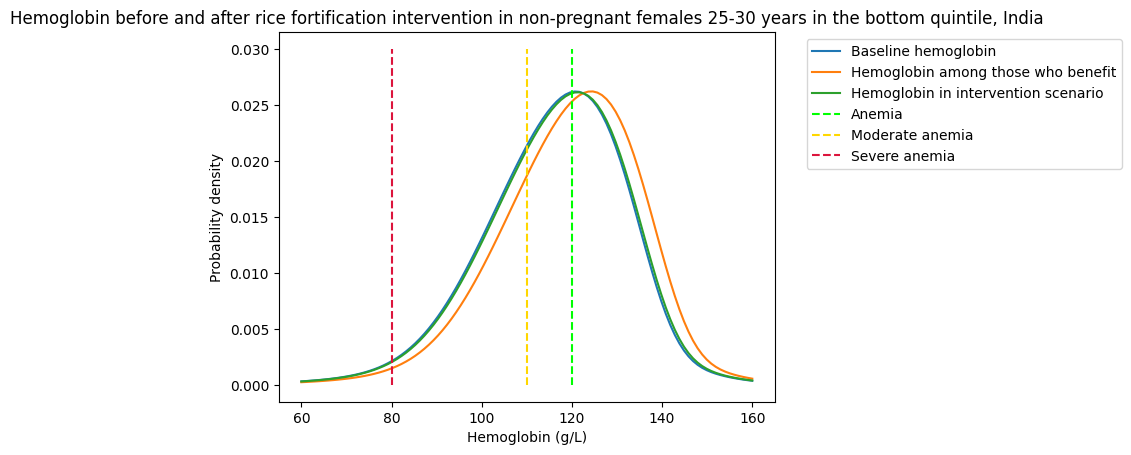

In [84]:
import matplotlib.pyplot as plt

x_values = np.linspace(60, 160, 100)
with np.errstate(under="ignore"):
    plt.plot(x_values, [baseline_pdf(x) for x in x_values], label="Baseline hemoglobin")
    plt.plot(x_values, [benefit_pdf(x) for x in x_values], label="Hemoglobin among those who benefit")
    plt.plot(x_values, [intervention_pdf(x) for x in x_values], label="Hemoglobin in intervention scenario")
    plt.vlines(thresholds.loc[("Female", 25, 30, 0)].hgb_upper_mild, 0, 0.03, linestyles="dashed", label="Anemia", color="lime")
    plt.vlines(thresholds.loc[("Female", 25, 30, 0)].hgb_upper_moderate, 0, 0.03, linestyles="dashed", label="Moderate anemia", color="gold")
    plt.vlines(thresholds.loc[("Female", 25, 30, 0)].hgb_upper_severe, 0, 0.03, linestyles="dashed", label="Severe anemia", color="crimson")
    plt.xlabel("Hemoglobin (g/L)")
    plt.ylabel("Probability density")
    plt.title(f"Hemoglobin before and after {vehicle} fortification intervention in non-pregnant females 25-30 years in the bottom quintile, {location.title()}")
    plt.legend(bbox_to_anchor=(1.05, 1))

In [85]:
(baseline_anemia - intervention_anemia).sort_values("anemic")

severe  moderate  \
sex  age_start age_end  wealth_quintile draw                               
Male 0.0       0.019178 lowest          draw_475  6.025843e-07  0.045201   
                                        draw_210  1.365818e-06  0.042286   
                                        draw_47   4.113670e-07  0.044133   
                                        draw_39   1.297605e-06  0.040070   
                                        draw_83   2.660725e-06  0.039366   
...                                                        ...       ...   
                        highest         draw_229  1.494226e-06  0.014751   
                                        draw_17   2.686255e-06  0.013687   
                                        draw_269  2.698083e-07  0.012507   
                                        draw_464  8.663912e-07  0.013436   
                                        draw_89   5.453170e-07  0.010346   

                                                      mild    anemic  
sex  age_start age_end  wealth_quintile draw                          
Male 0.0       0.019178 lowest          draw_475 -0.044960  0.000242  
                                        draw_210 -0.041995  0.000292  
                                        draw_47  -0.043830  0.000303  
                                        draw_39  -0.039559  0.000512  
                                        draw_83  -0.038851  0.000518  
...                                                    ...       ...  
                        highest         draw_229  0.031392  0.046145  
                                        draw_17   0.033456  0.047146  
                                        draw_269  0.034915  0.047423  
                                        draw_464  0.035465  0.048902  
                                        draw_89   0.043580  0.053926  

[125000 rows x 4 columns]

In [86]:
def anemia_to_yld_rates(anemia):
    disability_weights = pd.read_hdf('/mnt/team/simulation_science/costeffectiveness/auxiliary_data/GBD_2021/02_processed_data/disability_weight/sequela/all/all.hdf')
    disability_weights = disability_weights[disability_weights.healthstate.isin(['anemia_mild', 'anemia_mod', 'anemia_sev'])].set_index('healthstate').filter(like='draw_')
    disability_weights.columns.name = 'draw'
    disability_weights = disability_weights.stack().rename('disability_weight').reset_index()
    display(disability_weights)

    orig_index = anemia.index
    anemia = anemia.reset_index().merge(
        disability_weights[disability_weights.healthstate == 'anemia_mild'][['draw', 'disability_weight']].rename(columns={'disability_weight': 'mild_dw'}),
        validate="m:1",
    ).merge(
        disability_weights[disability_weights.healthstate == 'anemia_mod'][['draw', 'disability_weight']].rename(columns={'disability_weight': 'moderate_dw'}),
        validate="m:1",
    ).merge(
        disability_weights[disability_weights.healthstate == 'anemia_sev'][['draw', 'disability_weight']].rename(columns={'disability_weight': 'severe_dw'}),
        validate="m:1",
    )

    anemia["mild_yld_rate"] = anemia.mild * anemia.mild_dw
    anemia["moderate_yld_rate"] = anemia.moderate * anemia.moderate_dw
    anemia["severe_yld_rate"] = anemia.severe * anemia.severe_dw
    anemia['anemic_yld_rate'] = anemia['mild_yld_rate'] + anemia['moderate_yld_rate'] + anemia['severe_yld_rate']

    return anemia.set_index(orig_index.names).filter(like='yld_rate')

In [87]:
baseline_anemia_yld_rates = anemia_to_yld_rates(baseline_anemia)
baseline_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw                      
Female 0.0       0.019178   lowest          draw_0         0.000667   
                            second          draw_0         0.000847   
                            middle          draw_0         0.000866   
                            fourth          draw_0         0.001002   
                            highest         draw_0         0.001121   
...                                                             ...   
Male   95.0      125.000000 lowest          draw_499       0.000755   
                            second          draw_499       0.000757   
                            middle          draw_499       0.000749   
                            fourth          draw_499       0.000766   
                            highest         draw_499       0.000804   

                                                      moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw                          
Female 0.0       0.019178   lowest          draw_0             0.042038   
                            second          draw_0             0.037203   
                            middle          draw_0             0.036503   
                            fourth          draw_0             0.032433   
                            highest         draw_0             0.028919   
...                                                                 ...   
Male   95.0      125.000000 lowest          draw_499           0.014737   
                            second          draw_499           0.014474   
                            middle          draw_499           0.014233   
                            fourth          draw_499           0.014297   
                            highest         draw_499           0.014594   

                                                      severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw                        
Female 0.0       0.019178   lowest          draw_0           0.000736   
                            second          draw_0           0.000580   
                            middle          draw_0           0.000645   
                            fourth          draw_0           0.000523   
                            highest         draw_0           0.000358   
...                                                               ...   
Male   95.0      125.000000 lowest          draw_499         0.024377   
                            second          draw_499         0.023642   
                            middle          draw_499         0.023664   
                            fourth          draw_499         0.022640   
                            highest         draw_499         0.020818   

                                                      anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   lowest          draw_0           0.043441  
                            second          draw_0           0.038630  
                            middle          draw_0           0.038013  
                            fourth          draw_0           0.033958  
                            highest         draw_0           0.030399  
...                                                               ...  
Male   95.0      125.000000 lowest          draw_499         0.039868  
                            second          draw_499         0.038873  
                            middle          draw_499         0.038645  
                            fourth          draw_499         0.037703  
                            highest         draw_499         0.036216  

[125000 rows x 4 columns]

In [88]:
(baseline_anemia_yld_rates.loc[("Female", 25, 30, "lowest")].mean() - anemia_to_yld_rates(iron_responsive_with_fort_anemia).loc[("Female", 25, 30, "lowest")].mean()) / baseline_anemia_yld_rates.loc[("Female", 25, 30, "lowest")].mean()

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate        0.080991
moderate_yld_rate    0.205086
severe_yld_rate      0.267842
anemic_yld_rate      0.209752
dtype: float64

In [89]:
intervention_anemia_yld_rates = anemia_to_yld_rates(intervention_anemia)
intervention_anemia_yld_rates

,healthstate,draw,disability_weight
0,anemia_mild,draw_0,0.002420
1,anemia_mild,draw_1,0.003172
2,anemia_mild,draw_2,0.002644
3,anemia_mild,draw_3,0.003085
4,anemia_mild,draw_4,0.001845
...,...,...,...
2995,anemia_sev,draw_995,0.174969
2996,anemia_sev,draw_996,0.086798
2997,anemia_sev,draw_997,0.131996
2998,anemia_sev,draw_998,0.124427


mild_yld_rate  \
sex    age_start age_end    wealth_quintile draw                     
Female 0.0       0.019178   fourth          draw_0        0.001041   
                            highest         draw_0        0.001161   
                            lowest          draw_0        0.000715   
                            middle          draw_0        0.000910   
                            second          draw_0        0.000891   
...                                                            ...   
Male   95.0      125.000000 fourth          draw_99       0.000904   
                            highest         draw_99       0.000949   
                            lowest          draw_99       0.000900   
                            middle          draw_99       0.000885   
                            second          draw_99       0.000898   

                                                     moderate_yld_rate  \
sex    age_start age_end    wealth_quintile draw                         
Female 0.0       0.019178   fourth          draw_0            0.030919   
                            highest         draw_0            0.027074   
                            lowest          draw_0            0.040730   
                            middle          draw_0            0.035081   
                            second          draw_0            0.035848   
...                                                                ...   
Male   95.0      125.000000 fourth          draw_99           0.012603   
                            highest         draw_99           0.012828   
                            lowest          draw_99           0.012972   
                            middle          draw_99           0.012553   
                            second          draw_99           0.012758   

                                                     severe_yld_rate  \
sex    age_start age_end    wealth_quintile draw                       
Female 0.0       0.019178   fourth          draw_0          0.000488   
                            highest         draw_0          0.000328   
                            lowest          draw_0          0.000695   
                            middle          draw_0          0.000605   
                            second          draw_0          0.000547   
...                                                              ...   
Male   95.0      125.000000 fourth          draw_99         0.026928   
                            highest         draw_99         0.024848   
                            lowest          draw_99         0.028851   
                            middle          draw_99         0.028040   
                            second          draw_99         0.028073   

                                                     anemic_yld_rate  
sex    age_start age_end    wealth_quintile draw                      
Female 0.0       0.019178   fourth          draw_0          0.032448  
                            highest         draw_0          0.028564  
                            lowest          draw_0          0.042139  
                            middle          draw_0          0.036597  
                            second          draw_0          0.037286  
...                                                              ...  
Male   95.0      125.000000 fourth          draw_99         0.040435  
                            highest         draw_99         0.038625  
                            lowest          draw_99         0.042722  
                            middle          draw_99         0.041479  
                            second          draw_99         0.041729  

[125000 rows x 4 columns]

In [90]:
(baseline_anemia_yld_rates - intervention_anemia_yld_rates).sort_values("anemic_yld_rate")

mild_yld_rate  \
sex    age_start age_end   wealth_quintile draw                     
Male   25.0      30.000000 second          draw_38       0.000004   
                           highest         draw_38       0.000006   
                           fourth          draw_38       0.000005   
                           lowest          draw_38       0.000004   
                           middle          draw_38       0.000005   
...                                                           ...   
       0.0       0.019178  lowest          draw_39      -0.000155   
Female 0.0       0.019178  middle          draw_45      -0.000257   
       0.5       1.000000  highest         draw_45       0.000073   
       0.0       0.019178  fourth          draw_45      -0.000243   
                           highest         draw_45      -0.000257   

                                                    moderate_yld_rate  \
sex    age_start age_end   wealth_quintile draw                         
Male   25.0      30.000000 second          draw_38           0.000017   
                           highest         draw_38           0.000017   
                           fourth          draw_38           0.000018   
                           lowest          draw_38           0.000018   
                           middle          draw_38           0.000020   
...                                                               ...   
       0.0       0.019178  lowest          draw_39           0.002666   
Female 0.0       0.019178  middle          draw_45           0.002834   
       0.5       1.000000  highest         draw_45           0.002416   
       0.0       0.019178  fourth          draw_45           0.003015   
                           highest         draw_45           0.003644   

                                                    severe_yld_rate  \
sex    age_start age_end   wealth_quintile draw                       
Male   25.0      30.000000 second          draw_38     2.768823e-06   
                           highest         draw_38     2.595767e-06   
                           fourth          draw_38     2.920128e-06   
                           lowest          draw_38     2.739552e-06   
                           middle          draw_38     3.390145e-06   
...                                                             ...   
       0.0       0.019178  lowest          draw_39     2.640947e-07   
Female 0.0       0.019178  middle          draw_45     2.443207e-05   
       0.5       1.000000  highest         draw_45     1.507361e-04   
       0.0       0.019178  fourth          draw_45     2.110356e-05   
                           highest         draw_45     1.738611e-05   

                                                    anemic_yld_rate  
sex    age_start age_end   wealth_quintile draw                      
Male   25.0      30.000000 second          draw_38         0.000024  
                           highest         draw_38         0.000025  
                           fourth          draw_38         0.000025  
                           lowest          draw_38         0.000025  
                           middle          draw_38         0.000028  
...                                                             ...  
       0.0       0.019178  lowest          draw_39         0.002511  
Female 0.0       0.019178  middle          draw_45         0.002601  
       0.5       1.000000  highest         draw_45         0.002640  
       0.0       0.019178  fourth          draw_45         0.002793  
                           highest         draw_45         0.003404  

[125000 rows x 4 columns]

In [91]:
assert ((baseline_anemia_yld_rates - intervention_anemia_yld_rates).anemic_yld_rate > 0).all()

In [92]:
baseline_ylds = (baseline_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1) * non_pregnant_pop)
baseline_ylds

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    fourth             1059.997610
                               highest             769.541848
                               lowest             1801.271863
                               middle             1244.355229
                               second             1419.783311
                                                     ...     
Male    95.0       125.000000  fourth              894.100061
                               highest            1059.690219
                               lowest              827.604317
                               middle              868.092670
                               second              844.438359
Length: 250, dtype: float64

In [93]:
intervention_ylds = (intervention_anemia_yld_rates.anemic_yld_rate.unstack("draw").mean(axis=1) * non_pregnant_pop)
intervention_ylds

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    fourth             1018.412572
                               highest             728.957185
                               lowest             1751.824109
                               middle             1202.910269
                               second             1375.563432
                                                     ...     
Male    95.0       125.000000  fourth              881.628516
                               highest            1037.768575
                               lowest              819.813889
                               middle              857.854704
                               second              835.741490
Length: 250, dtype: float64

In [94]:
(baseline_ylds.loc[("Female", 25, 30, "lowest")].mean() - intervention_ylds.loc[("Female", 25, 30, "lowest")].mean())

5175.238994259911

In [95]:
baseline_ylds.groupby(["wealth_quintile"]).sum() - intervention_ylds.groupby(["wealth_quintile"]).sum()

wealth_quintile
fourth     126845.724090
highest    159111.188550
lowest     116450.118423
middle     121364.871061
second     110837.709293
dtype: float64

In [96]:
ylds = pd.concat([
    baseline_ylds.rename("value").reset_index().assign(scenario="baseline"),
    intervention_ylds.rename("value").reset_index().assign(scenario="intervention")
], ignore_index=True)
ylds

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,fourth,1059.997610,baseline
1,Female,0.0,0.019178,highest,769.541848,baseline
2,Female,0.0,0.019178,lowest,1801.271863,baseline
3,Female,0.0,0.019178,middle,1244.355229,baseline
4,Female,0.0,0.019178,second,1419.783311,baseline
...,...,...,...,...,...,...
495,Male,95.0,125.000000,fourth,881.628516,intervention
496,Male,95.0,125.000000,highest,1037.768575,intervention
497,Male,95.0,125.000000,lowest,819.813889,intervention
498,Male,95.0,125.000000,middle,857.854704,intervention


In [97]:
results_dir = f'./results/{vehicle.lower()}/{location.lower()}/{intervention_scenario.lower()}'

In [98]:
path = f'{results_dir}/ylds.parquet'
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
ylds.to_parquet(path)

In [99]:
baseline_anemia_prevalence = baseline_anemia['anemic'].unstack("draw").mean(axis=1)
baseline_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    fourth             0.917220
                               highest            0.900539
                               lowest             0.965487
                               middle             0.940266
                               second             0.947353
                                                    ...   
Male    95.0       125.000000  fourth             0.762443
                               highest            0.763989
                               lowest             0.784717
                               middle             0.765232
                               second             0.772893
Length: 250, dtype: float64

In [100]:
baseline_anemia_cases = baseline_anemia_prevalence.mul(non_pregnant_pop, axis=0)
baseline_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    fourth             33424.279506
                               highest            26298.067393
                               lowest             47936.142149
                               middle             36378.268813
                               second             41281.501854
                                                      ...     
Male    95.0       125.000000  fourth             13163.809909
                               highest            16264.929961
                               lowest             11909.410763
                               middle             12526.984211
                               second             12249.198027
Length: 250, dtype: float64

In [101]:
baseline_anemia_cases.sum() / non_pregnant_pop.sum()

0.4130474930130347

In [102]:
baseline_anemia_cases.groupby(["wealth_quintile"]).sum() / non_pregnant_pop.groupby(["wealth_quintile"]).sum()

wealth_quintile
fourth     0.392112
highest    0.367032
lowest     0.464735
middle     0.416044
second     0.426803
dtype: float64

In [103]:
intervention_anemia_prevalence = intervention_anemia['anemic'].unstack("draw").mean(axis=1)
intervention_anemia_prevalence

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    fourth             0.904618
                               highest            0.882312
                               lowest             0.960168
                               middle             0.931191
                               second             0.939494
                                                    ...   
Male    95.0       125.000000  fourth             0.756904
                               highest            0.755858
                               lowest             0.781009
                               middle             0.760531
                               second             0.768811
Length: 250, dtype: float64

In [104]:
anemia_prevalence = pd.concat([
    baseline_anemia_prevalence.rename("value").reset_index().assign(scenario="baseline"),
    intervention_anemia_prevalence.rename("value").reset_index().assign(scenario="intervention")
], ignore_index=True)
anemia_prevalence

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,fourth,0.917220,baseline
1,Female,0.0,0.019178,highest,0.900539,baseline
2,Female,0.0,0.019178,lowest,0.965487,baseline
3,Female,0.0,0.019178,middle,0.940266,baseline
4,Female,0.0,0.019178,second,0.947353,baseline
...,...,...,...,...,...,...
495,Male,95.0,125.000000,fourth,0.756904,intervention
496,Male,95.0,125.000000,highest,0.755858,intervention
497,Male,95.0,125.000000,lowest,0.781009,intervention
498,Male,95.0,125.000000,middle,0.760531,intervention


In [105]:
path = f'{results_dir}/anemia_prevalence.parquet'
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
anemia_prevalence.to_parquet(path)

In [106]:
intervention_anemia_cases = intervention_anemia_prevalence.mul(non_pregnant_pop, axis=0)
intervention_anemia_cases

sex     age_start  age_end     wealth_quintile
Female  0.0        0.019178    fourth             32965.024988
                               highest            25765.801375
                               lowest             47672.068502
                               middle             36027.190657
                               second             40939.036132
                                                      ...     
Male    95.0       125.000000  fourth             13068.179942
                               highest            16091.818802
                               lowest             11853.135866
                               middle             12450.025500
                               second             12184.504032
Length: 250, dtype: float64

In [107]:
intervention_anemia_cases.sum() / non_pregnant_pop.sum()

0.40100343465482335

In [108]:
intervention_anemia_cases.groupby(["wealth_quintile"]).sum() / non_pregnant_pop.groupby(["wealth_quintile"]).sum()

wealth_quintile
fourth     0.379946
highest    0.350830
lowest     0.454436
middle     0.404801
second     0.416571
dtype: float64

In [109]:
(baseline_anemia_cases.groupby(["wealth_quintile"]).sum() - intervention_anemia_cases.groupby(["wealth_quintile"]).sum()).map(lambda x: f'{round(x):,.0f}')

wealth_quintile
fourth     3,411,621
highest    4,563,075
lowest     2,824,588
middle     3,139,989
second     2,840,077
dtype: object

In [110]:
anemia_cases = pd.concat([
    baseline_anemia_cases.rename("value").reset_index().assign(scenario="baseline"),
    intervention_anemia_cases.rename("value").reset_index().assign(scenario="intervention")
], ignore_index=True)
anemia_cases

,sex,age_start,age_end,wealth_quintile,value,scenario
0,Female,0.0,0.019178,fourth,33424.279506,baseline
1,Female,0.0,0.019178,highest,26298.067393,baseline
2,Female,0.0,0.019178,lowest,47936.142149,baseline
3,Female,0.0,0.019178,middle,36378.268813,baseline
4,Female,0.0,0.019178,second,41281.501854,baseline
...,...,...,...,...,...,...
495,Male,95.0,125.000000,fourth,13068.179942,intervention
496,Male,95.0,125.000000,highest,16091.818802,intervention
497,Male,95.0,125.000000,lowest,11853.135866,intervention
498,Male,95.0,125.000000,middle,12450.025500,intervention


In [111]:
path = f'{results_dir}/anemia_cases.parquet'
pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
anemia_cases.to_parquet(path)